In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie
import prism.modeling.display # importing the display module enables the model display features

plt.rcParams['axes.xmargin'] = 0

In [2]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

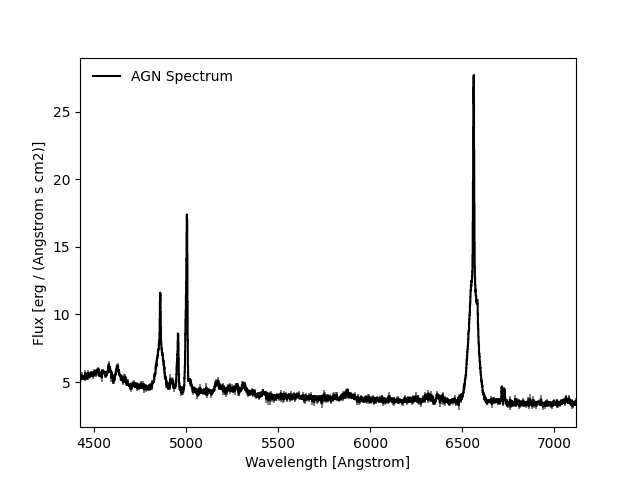

In [3]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# # (Example) Crop a portion of the spectrum
# wbounds = (4800., 7500.) # Å
# spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.plot_spectrum() 

In [4]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4424.778761061947, 7117.303709282621]


In [5]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 0. # km/s


# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [6]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x0=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x0': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [7]:
from prism.modeling import instrument

# Create the wavelength grid in the observer frame (not redshift corrected)
# Standard grid for agnspec.txt: 4700 to 7560 Angstrom
wave_obs = np.arange(4700, 7561.25, 1.25)

# Define the FWHM gradient from 100 to 120 km/s
fwhm_kms = np.linspace(100, 120, len(wave_obs))

# Convert FWHM from km/s to Angstrom: FWHM_ang = (v / c) * lambda
from astropy.constants import c
c_kms = c.to('km/s').value
fwhm_ang = (fwhm_kms / c_kms) * wave_obs

# Calculate Gaussian sigma values
sigmas = fwhm_ang / (2 * np.sqrt(2 * np.log(2)))

# Build the sparse response matrix
# Using the internal helper from InstrumentResponse
matrix = instrument.InstrumentResponse._build_sparse_gaussian_matrix(wave_obs, sigmas)

# Create the InstrumentResponse instance (temporary, not saved to disk)
custom_ir = instrument.InstrumentResponse(wave_obs, matrix)

# Apply to the model using SpectralResponse (passing the instance directly)
# This keeps it temporary for this session and does not write to the archive.
lsf = instrument.SpectralResponse(instrument=custom_ir, wave=spec.wave, z=spec.z, name='lsf')
model = model | lsf # Apply the response


In [8]:
model

<CompoundModel((bknpower + blr + nlr + hhe_nlr + oiii + fe) | lsf; amplitude_0=3.92125, x0_0=5450, index1_0=-2, index2_0=0, ...)>

In [9]:
fitter = fitting.TRFLSQFitter()
fitter.max_evaluations = 5000

# fitter = fitting.SherpaLM() # It depends case by case, but very robust alternative for bounded problems to astropy defaults! Ensure to have Sherpa installed in your environment.

fitted_model = fitter(model=model, x=spec.wave, y=spec.flux, yerr=spec.err, inplace=True)

/Users/pierpaolo/SciSoft/git/prism-spec/prism/modeling/fitting/extension.py:318: UserWarning: 
Prism detected tied parameters together with analytic derivatives available.
If analytic derivatives are being used, tie sensitivities are being estimated
numerically to reduce the Jacobian to the free parameters.
This is usually reliable for smooth ties, but can be inaccurate near non-smooth
links or active bounds. If the fit looks suspicious, retry with a numeric Jacobian
in the fitter settings, e.g. prism.modeling.fitting.ScipyTRF(jac='2-point')
  corrected = _reduce_tied_analytic_jacobian(


In [10]:
# Compute chi-squared
residuals = spec.flux - fitted_model(spec.wave)
chi_squared = np.sum((residuals / spec.err) ** 2)

print(f"Chi-squared: {chi_squared:.2f}")

Chi-squared: 2778.61


In [11]:
# Manually print the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'std') and param.std is not None:
        print(f"  {name:16s}: {param.value:8.4f} ± {param.std:2g}")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     :   3.9133 ± 0.00138998
  x0_0            : 5485.0966 ± 2.6322
  index1_0        :  -1.2529 ± 0.00319381
  index2_0        :   0.6744 ± 0.00341254
  amp_hb4861_1    :   3.1989 ± 0.00193886
  amp_ha6562_1    :   9.2669 ± 0.010364
  amp_hei4471_1   :   0.2040 ± 0.00966769
  amp_heii4685_1  :   0.0012 ± 0.00546098
  amp_hei5877_1   :   0.3472 ± 0.000713613
  amp_hei6678_1   :   0.1439 ± 0.00154731
  amp_hei7065_1   :   0.1960 ± 0.00181811
  offset_1        : -131.3721 ± 0.456845
  fwhm_1          : 2502.2028 ± 0.791454
  redshift_1      :   0.0000
  amp_oiii5007_2  :   8.6567 ± 0.0596175
  amp_nii6583_2   :   1.7204 ± 0.0241181
  amp_oi6300_2    :   0.1178 ± 0.0188743
  amp_oi6363_2    :   0.4367 ± 0.01273
  amp_sii6716_2   :   1.1531 ± 0.01322
  amp_sii6730_2   :   0.9371 ± 0.00123568
  offset_2        : -58.9714 ± 0.244299
  fwhm_2          : 273.2843 ± 0.592315
  redshift_2      :   0.0000
  amp_hb4861_3    :   4.5422 ± 0.0300512
  amp_ha6562_3    :  15.8963 ± 0.04596

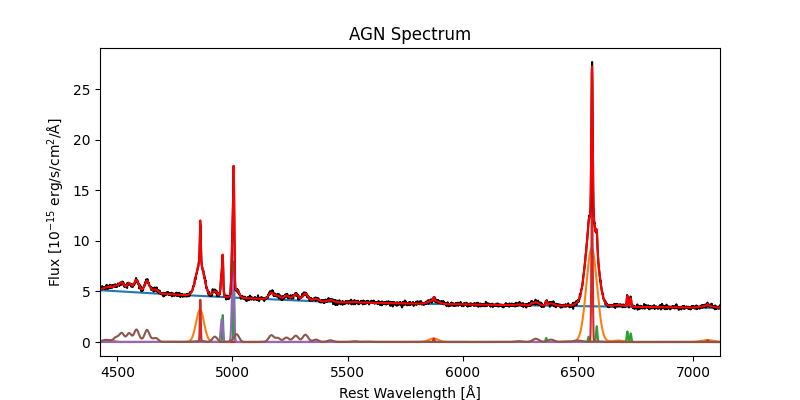

In [12]:
plt.figure(figsize=(8, 4))

comps = models.get_components(model, additive=True)
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, label='Data', color='black')
plt.plot(spec.wave, model(spec.wave), label='Model', color='red')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel('Flux [10$^{-15}$ erg/s/cm$^2$/Å]')

# plt.ylim(bottom=0.1)
# plt.yscale('log')

plt.title(spec.name)

plt.show()

In [13]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim,unit
[OIII]5007,55.931269,0.403817,NaN,NaN,None
[NII]6583,14.630793,0.207549,NaN,NaN,None
[OI]6300,0.719919,0.115375,NaN,NaN,None
[OI]6363,2.696280,0.078810,NaN,NaN,None
[SII]6716,7.513881,0.087667,NaN,NaN,None
[SII]6730,6.118925,0.015524,NaN,NaN,None


In [14]:
# If the fitter uses covariance in the fitting process, by default we will add the .std attribute to the parameters of the model.
# In some cases you might want to estimate the uncertainties on the best-fit parameters using more robust methods, such as bootstrapping.
# We implement it in an easy way in prism, and it can be used with any of the available fitters.
# We perturb the data around their uncertainties, and we refit the model to each perturbed dataset.
# This will give us a distribution of best-fit parameters from which we can estimate the uncertainties.
# We supprt parallelized fitting! For simple models and small datasets, you can set nproc=1 to avoid the overhead of parallelization.
# For more complex models and larger datasets, you can increase nproc to speed up the process.

from prism.modeling.fitting.uncertainty import bootstrap

fitter = fitting.TRFLSQFitter()
fitter.max_evaluations = 5000

# fitter = fitting.ScipyTRF()

# fitter = fitting.SherpaLM()

samples = bootstrap(model=fitted_model, 
                    fitter=fitter,
                    x=spec.wave, y=spec.flux, yerr=spec.err,
                    n_samples=200, seed=11,
                    nproc=4,
                    noise_dist='uniform'
                    )

Fitting spectra:   0%|          | 0/200 [00:00<?, ?it/s]

/Users/pierpaolo/SciSoft/git/prism-spec/prism/modeling/fitting/extension.py:318: UserWarning: 
Prism detected tied parameters together with analytic derivatives available.
If analytic derivatives are being used, tie sensitivities are being estimated
numerically to reduce the Jacobian to the free parameters.
This is usually reliable for smooth ties, but can be inaccurate near non-smooth
links or active bounds. If the fit looks suspicious, retry with a numeric Jacobian
in the fitter settings, e.g. prism.modeling.fitting.ScipyTRF(jac='2-point')
  corrected = _reduce_tied_analytic_jacobian(
/Users/pierpaolo/SciSoft/git/prism-spec/prism/modeling/fitting/extension.py:318: UserWarning: 
Prism detected tied parameters together with analytic derivatives available.
If analytic derivatives are being used, tie sensitivities are being estimated
numerically to reduce the Jacobian to the free parameters.
This is usually reliable for smooth ties, but can be inaccurate near non-smooth
links or active b

In [15]:
# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'lolim') and param.lolim is not None:
        print(f"  {name:16s}: [{param.lolim:8.4f}, {param.uplim:8.4f}]")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     : [  3.9112,   3.9141]
  x0_0            : [5484.6792, 5488.1272]
  index1_0        : [ -1.2530,  -1.2482]
  index2_0        : [  0.6690,   0.6749]
  amp_hb4861_1    : [  3.1983,   3.2011]
  amp_ha6562_1    : [  9.2669,   9.3293]
  amp_hei4471_1   : [  0.1752,   0.2040]
  amp_heii4685_1  : [     nan,   0.0145]
  amp_hei5877_1   : [  0.3469,   0.3486]
  amp_hei6678_1   : [  0.1411,   0.1439]
  amp_hei7065_1   : [  0.1934,   0.1993]
  offset_1        : [-131.3721, -129.7212]
  fwhm_1          : [2499.6813, 2502.2028]
  redshift_1      :   0.0000
  amp_oiii5007_2  : [  8.5455,   8.7497]
  amp_nii6583_2   : [  1.6228,   1.7204]
  amp_oi6300_2    : [  0.0712,   0.1178]
  amp_oi6363_2    : [  0.3409,   0.4367]
  amp_sii6716_2   : [  1.1081,   1.1531]
  amp_sii6730_2   : [  0.9371,   0.9529]
  offset_2        : [-64.2149, -58.9714]
  fwhm_2          : [273.2843, 280.0752]
  redshift_2      :   0.0000
  amp_hb4861_3    : [  4.5422,   4.9223]
  amp_ha6562_3    : [ 15.4423,  15

In [16]:
# Print the paramters with fluxes
components = models.get_components(fitted_model)

for i, name in enumerate(components.names):
    comp = components[i]

    if isinstance(comp, models.LineGroupBase):
        for line in comp.lines[comp.lines['weight'] == 1]['name']: # Drop lines with weight!=1. Repeated entries otherwise.
            flux = comp.flux.loc[line, 'value']
            flux_limits = comp.flux.loc[line, ['lolim', 'uplim']]
            if flux_limits.notnull().any():
                print(f"  {name:12s} flux_{line:15s} [{flux_limits['lolim']:8.4f}, {flux_limits['uplim']:8.4f}]")
            else:
                print(f"  {name:12s} flux_{line:15s} {flux:8.4f} ± {comp.flux.loc[line, 'std']:2g}")

    for parname in comp.param_names:
        param = getattr(comp, parname)
        if hasattr(param, 'lolim') and param.lolim is not None:
            print(f"  {name:12s} {parname:20s} [{param.lolim:8.4f}, {param.uplim:8.4f}]")
        else:
            print(f"  {name:12s} {parname:20s} {param.value:8.4f}")


  bknpower|lsf amplitude_0          [  3.9112,   3.9141]
  bknpower|lsf x0_0                 [5484.6792, 5488.1272]
  bknpower|lsf index1_0             [ -1.2530,  -1.2482]
  bknpower|lsf index2_0             [  0.6690,   0.6749]
  blr|lsf      amp_hb4861_0         [  3.1983,   3.2011]
  blr|lsf      amp_ha6562_0         [  9.2669,   9.3293]
  blr|lsf      amp_hei4471_0        [  0.1752,   0.2040]
  blr|lsf      amp_heii4685_0       [     nan,   0.0145]
  blr|lsf      amp_hei5877_0        [  0.3469,   0.3486]
  blr|lsf      amp_hei6678_0        [  0.1411,   0.1439]
  blr|lsf      amp_hei7065_0        [  0.1934,   0.1993]
  blr|lsf      offset_0             [-131.3721, -129.7212]
  blr|lsf      fwhm_0               [2499.6813, 2502.2028]
  blr|lsf      redshift_0             0.0000
  nlr|lsf      amp_oiii5007_0       [  8.5455,   8.7497]
  nlr|lsf      amp_nii6583_0        [  1.6228,   1.7204]
  nlr|lsf      amp_oi6300_0         [  0.0712,   0.1178]
  nlr|lsf      amp_oi6363_0         [

In [17]:
from prism.utils import fmt

# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {fmt(value=value, lo=lolim, hi=uplim)}")


  amplitude_0     : 3.9133 [-0.0021, +0.0009]
  x0_0            : 5485.1 [-0.5, +3.0]
  index1_0        : -1.2523 [-0.0007, +0.0041]
  index2_0        : 0.6742 [-0.0052, +0.0007]
  amp_hb4861_1    : 3.1991 [-0.0008, +0.0020]
  amp_ha6562_1    : 9.30 [-0.04, +0.03]
  amp_hei4471_1   : 0.19 [-0.02, +0.01]
  amp_heii4685_1  : < 0.01
  amp_hei5877_1   : 0.3473 [-0.0004, +0.0013]
  amp_hei6678_1   : 0.1429 [-0.0018, +0.0010]
  amp_hei7065_1   : 0.196 ± 0.003
  offset_1        : -130.5 ± 0.8
  fwhm_1          : 2501 ± 1
  redshift_1      : 0
  amp_oiii5007_2  : 8.66 [-0.11, +0.09]
  amp_nii6583_2   : 1.66 [-0.04, +0.06]
  amp_oi6300_2    : 0.10 [-0.03, +0.01]
  amp_oi6363_2    : 0.37 [-0.03, +0.07]
  amp_sii6716_2   : 1.13 ± 0.02
  amp_sii6730_2   : 0.947 [-0.010, +0.006]
  offset_2        : -63.5 [-0.7, +4.5]
  fwhm_2          : 278 [-5, +2]
  redshift_2      : 0
  amp_hb4861_3    : 4.82 [-0.28, +0.10]
  amp_ha6562_3    : 15.8 [-0.4, +0.1]
  amp_hei4471_3   : 0.18 [-0.02, +0.03]
  amp_heii4

In [18]:
from prism.utils import tex

for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {tex(value=value, lo=lolim, hi=uplim, use_sci=True, maxexp=4)}")

  amplitude_0     : 3.9133_{-0.0021}^{+0.0009}
  x0_0            : 5485.1_{-0.5}^{+3.0}
  index1_0        : -1.2523_{-0.0007}^{+0.0041}
  index2_0        : 0.6742_{-0.0052}^{+0.0007}
  amp_hb4861_1    : 3.1991_{-0.0008}^{+0.0020}
  amp_ha6562_1    : 9.30_{-0.04}^{+0.03}
  amp_hei4471_1   : 0.19_{-0.02}^{+0.01}
  amp_heii4685_1  : < 0.01
  amp_hei5877_1   : 0.3473_{-0.0004}^{+0.0013}
  amp_hei6678_1   : 0.1429_{-0.0018}^{+0.0010}
  amp_hei7065_1   : 0.196 \pm 0.003
  offset_1        : -130.5 \pm 0.8
  fwhm_1          : 2501 \pm 1
  redshift_1      : 0
  amp_oiii5007_2  : 8.66_{-0.11}^{+0.09}
  amp_nii6583_2   : 1.66_{-0.04}^{+0.06}
  amp_oi6300_2    : 0.10_{-0.03}^{+0.01}
  amp_oi6363_2    : 0.37_{-0.03}^{+0.07}
  amp_sii6716_2   : 1.13 \pm 0.02
  amp_sii6730_2   : 0.947_{-0.010}^{+0.006}
  offset_2        : -63.5_{-0.7}^{+4.5}
  fwhm_2          : 278_{-5}^{+2}
  redshift_2      : 0
  amp_hb4861_3    : 4.82_{-0.28}^{+0.10}
  amp_ha6562_3    : 15.8_{-0.4}^{+0.1}
  amp_hei4471_3   : 0.18_

In [19]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim,unit
[OIII]5007,56.968606,0.879920,55.212242,57.935891,None
[NII]6583,14.405387,0.413185,13.801142,14.994127,None
[OI]6300,0.651173,0.163494,0.435371,0.737797,None
[OI]6363,2.308026,0.226097,2.104358,2.763239,None
[SII]6716,7.503118,0.150949,7.219993,7.700477,None
[SII]6730,6.298686,0.072356,6.118833,6.376580,None


In [20]:
fe.flux

,value,std,lolim,uplim,unit
a4G,7.233768e+01,0.256478,71.913664,72.638842,None
a4H,1.331674e+00,0.118374,1.209182,1.474026,None
a6S,5.396220e+01,0.475571,53.318761,54.343402,None
b2H,4.835555e-04,0.123939,NaN,0.148339,None
b4D,4.329787e-02,0.045050,NaN,0.065074,None
b4F,8.165003e+01,0.401701,81.276964,82.368481,None
b4P,1.793443e+01,0.303778,17.699203,18.228810,None
z4D,3.098639e+01,0.232609,30.796825,31.344302,None
z4F,2.847634e+00,0.089015,2.763094,2.955396,None
y4G,1.255466e+01,0.362158,12.246028,13.007237,None


In [21]:
# Access specific entry (pandas.DataFrame)
fe.flux.loc['a4G', 'value']

np.float64(72.33767641701455)

In [22]:
nlr.lines

name,position,weight
,Angstrom,
str10,float64,float64
[OIII]5007,4958.911,0.33333333
[OIII]5007,5006.843,1.0
[NII]6583,6548.05,0.33333333
[NII]6583,6583.45,1.0
[OI]6300,6300.304,1.0
[OI]6363,6363.776,1.0
[SII]6716,6716.44,1.0
[SII]6730,6730.81,1.0


In [23]:
nlr.eqw() # Compute the Equivalent Width of the line. By default it uses the local continuum, but you can also specify a different continuum model if you want.

# Access the computed EW
nlr.ew

,value,std,lolim,uplim,unit
[OIII]5007,1.155318e+30,1.784468e+28,1.119699e+30,1.174934e+30,None
[NII]6583,3.228836e+09,9.261156e+07,3.093400e+09,3.360797e+09,None
[OI]6300,7.192320e+00,1.805821e+00,4.808744e+00,8.149094e+00,None
[OI]6363,7.264779e+00,7.116658e-01,6.623711e+00,8.697612e+00,None
[SII]6716,7.667374e+00,1.542540e-01,7.378051e+00,7.869054e+00,None
[SII]6730,7.683779e+00,8.826773e-02,7.464375e+00,7.778801e+00,None


In [24]:
fitted_model.show()

In [25]:
# The user can also save the fitted model and its parameters to a file, and load them later for inspection or further analysis, without the need to re-run the fitting process from scratch.
from prism.modeling.io import load_params, load_model

outfile = "results/agnmodel.fits"
fitted_model.save(outfile, overwrite=True)

lp = load_params(outfile)
lm = load_model(outfile)
print("amp_hb:", lp["amp_hb4861_1"])
print("model class:", type(lm).__name__)

/Users/pierpaolo/SciSoft/git/prism-spec/.venv/lib/python3.11/site-packages/yaml/representer.py:27: UserWarning: Linear-operator pipe model has no reconstruction recipe. The model will be saved without the response operator. Re-apply the response after loading.
  node = self.represent_data(data)


amp_hb: 3.1991078460848215
model class: CompoundModel


/Users/pierpaolo/SciSoft/git/prism-spec/.venv/lib/python3.11/site-packages/yaml/constructor.py:100: UserWarning: Model was saved with a direct response matrix that cannot be reconstructed from a recipe.  Re-apply the response manually.
  data = constructor(self, node)
